In [22]:
import pandas as pd
import numpy as np
import networkx as nx
import scipy
import matplotlib.pyplot as plt
import seaborn as sns

import markov_clustering as mc
import networkx as nx
from networkx.drawing.nx_agraph import graphviz_layout

In [2]:
threshold = 0.1
differential_regulation = pd.read_csv(f'./data/GW_diff_regulatorts_{threshold}.csv', index_col = 0)

In [3]:
differential_regulation = differential_regulation.drop_duplicates()

In [4]:
G = nx.from_pandas_edgelist(differential_regulation, source = 'TF', target='TG', edge_attr='abs_diff', create_using = nx.DiGraph)

In [28]:
matrix = nx.to_numpy_array(G)
result = mc.run_mcl(matrix)
clusters = mc.get_clusters(result)

In [37]:
node_index = {}
for index, gene in enumerate(G.nodes()):
    node_index[index] = gene

In [87]:
gene_clusters = []
cluster_lengths = []
for cluster in clusters:
    gene_cluster = []
    for index in cluster:
        gene_cluster.append(node_index[index])
    cluster_lengths.append(len(gene_cluster))
    gene_clusters.append(gene_cluster)

In [80]:
print(np.sort(cluster_lengths)[-10:])

[23 24 27 28 34 34 53 55 92 97]


In [95]:
cluster_lengths.index(53)

98

In [96]:
for gene in gene_clusters[98]:
    print(gene)

NR1I3
HBP1
MYT1
RFX5
ACBD6
L3MBTL1
ZNF490
ADGRE5
AFAP1L2
AJAP1
AMIGO2
ANKRD22
AOAH
APCDD1
CCDC125
CD2
CHRM2
CMKLR2
CNTFR
COX6C
CYP39A1
DCXR
DOCK8
DRC7
ERBB3
FAIM
FASN
FEZ2
FRMPD2
FYB1
GAPT
GIMAP5
GOLGA6D
GPC1
IFI27L2
KHDC4
LCN10
LRRC41
MAGED4B
MLC1
MS4A1
MS4A4A
NEFH
NEURL1
NME1
PCBD1
PPIC
PRELID3B
PRG4
SPR
UTP3
WEE1
ZMYM2


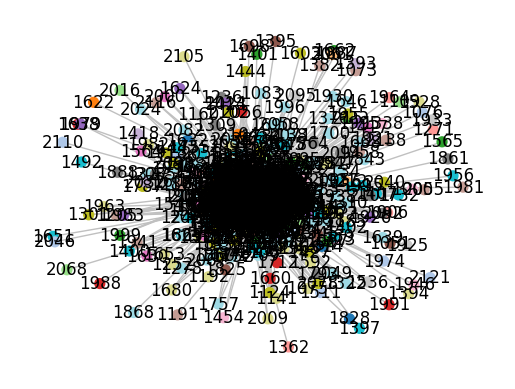

In [29]:
# Draw clusters
mc.draw_graph(matrix, clusters, node_size=50, with_labels=True, edge_color="silver")

KeyboardInterrupt: 

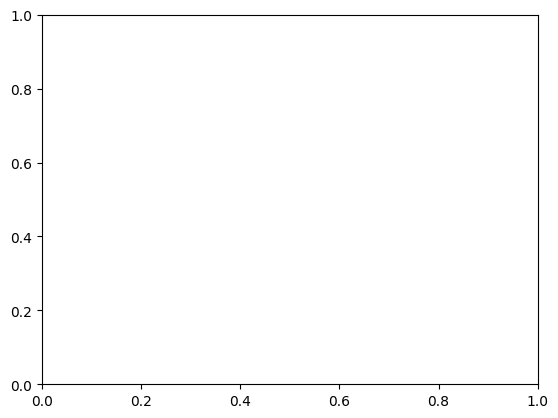

In [5]:
fig, ax = plt.subplots(ncols = 1)
pos = graphviz_layout(G, prog='dot', args="-Grankdir=LR")
nx.draw(G, ax = ax, node_size = 20, pos = pos)

# Graph properties statistics

In [6]:
#get list of gene names that are TFs only, TGs only, and both
DATA_ROOT = '../../data'
network = pd.read_csv(f'{DATA_ROOT}/Full data files/network(full).tsv', sep='\t')
TFs = set(differential_regulation['TF'])
TGs = set(differential_regulation['TG'])
TF_TGs = TFs & TGs
#mkae TFs set the TFs that are not also TGs
TFs = TFs - TF_TGs
TGs = TGs - TF_TGs
print(f'There are {len(TFs)} TFs and {len(TGs)} TGs. {len(TF_TGs)} TFs are also TGs')

There are 1004 TFs and 1078 TGs. 58 TFs are also TGs


In [7]:
in_degree_dict = {}
out_degree_dict = {}

for node in G.nodes():
    in_degree_dict[node] = G.in_degree(node)
    out_degree_dict[node] = G.out_degree(node)

In [8]:
TF_in_degrees = {k: in_degree_dict[k] for k in TFs}
TF_out_degrees = {k: out_degree_dict[k] for k in TFs}

In [9]:
TG_in_degrees = {k: in_degree_dict[k] for k in TGs}
TG_out_degrees = {k: out_degree_dict[k] for k in TGs}

In [10]:
TF_TG_in_degrees = {k: in_degree_dict[k] for k in TF_TGs}
TF_TG_out_degrees = {k: out_degree_dict[k] for k in TF_TGs}

Text(0.5, 0.98, 'Out Degree Distributions')

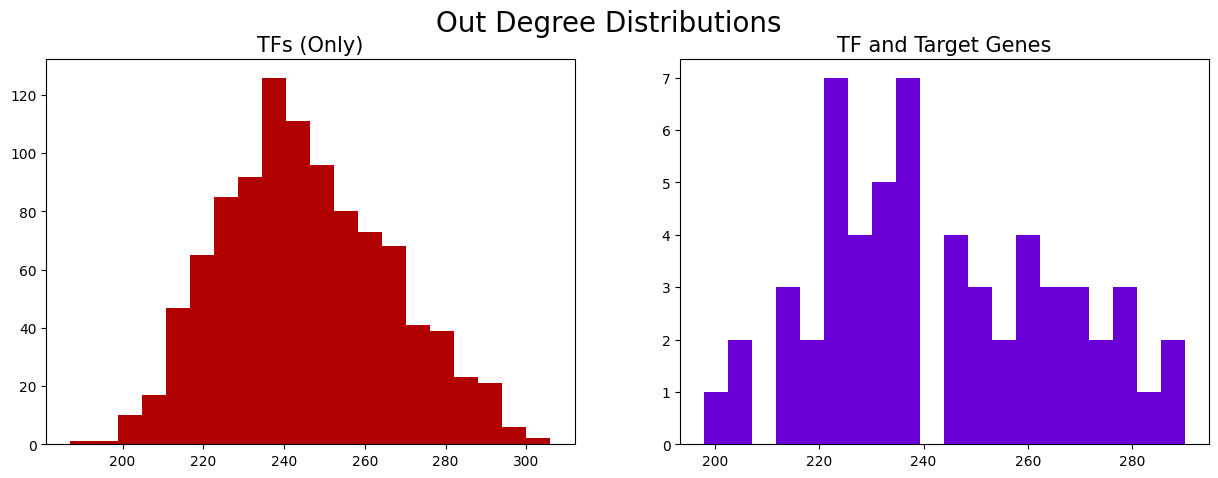

In [11]:
fig, ax = plt.subplots(ncols = 2, figsize = (15, 5))
ax[0].hist(TF_out_degrees.values(), bins = 20, color = '#b00000')
ax[0].set_title('TFs (Only)', fontsize = 15)
ax[1].hist(TF_TG_out_degrees.values(), bins = 20, color = '#6b00d6')
ax[1].set_title('TF and Target Genes', fontsize = 15)
fig.suptitle('Out Degree Distributions', fontsize = 20)

Text(0.5, 0.98, 'In Degree Distributions')

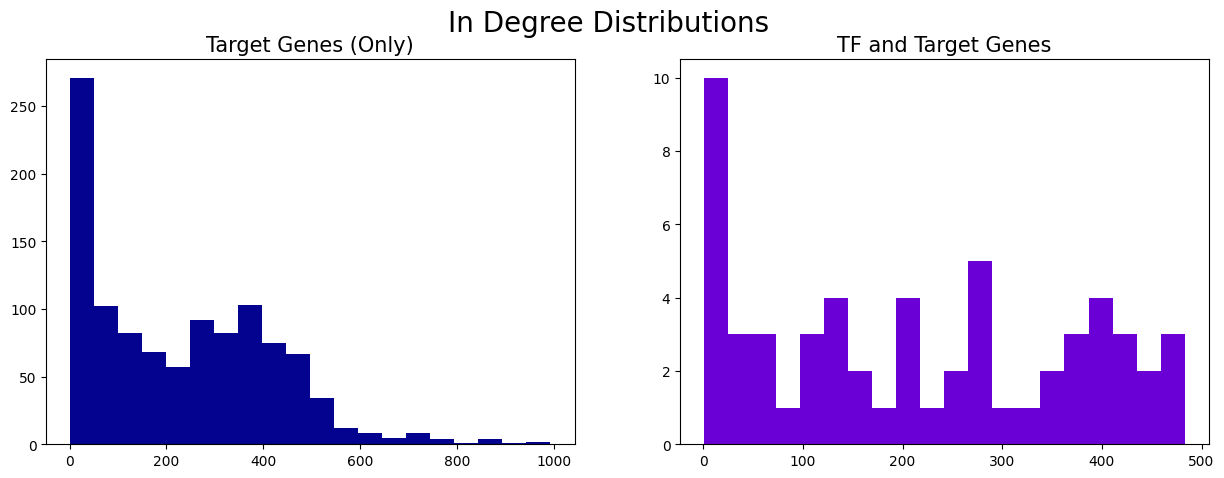

In [12]:
fig, ax = plt.subplots(ncols = 2, figsize = (15, 5))
ax[0].hist(TG_in_degrees.values(), bins = 20, color = '#03038f')
ax[0].set_title('Target Genes (Only)', fontsize = 15)
ax[1].hist(TF_TG_in_degrees.values(), bins = 20, color = '#6b00d6')
ax[1].set_title('TF and Target Genes', fontsize = 15)
fig.suptitle('In Degree Distributions', fontsize = 20)

In [13]:
degree_centralities = nx.degree_centrality(G)
TF_TG_centralities = {k: degree_centralities[k] for k in TF_TGs}

In [14]:
node_betweeness = nx.betweenness_centrality(G)
TF_TG_node_betweeness = {k: node_betweeness[k] for k in TF_TGs}

In [15]:
TFTG_df = pd.DataFrame([TF_TG_in_degrees, TF_TG_out_degrees, TF_TG_centralities, TF_TG_node_betweeness], index = ['in degree', 'out degree', 'Centrality', 'Betweeness']).T

Text(0.5, 1.0, 'TF-TG Connectedness')

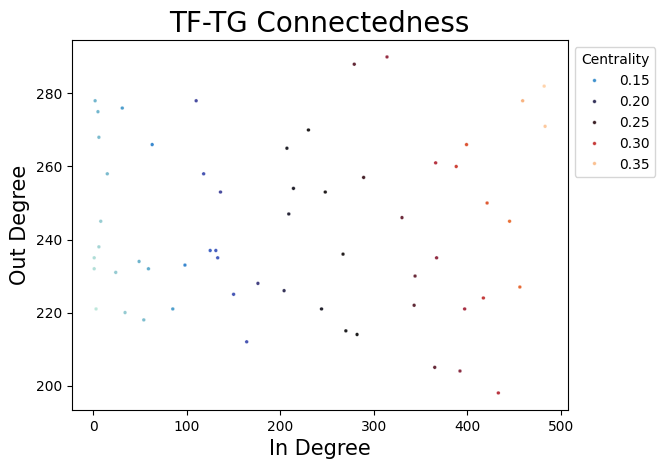

In [16]:
fig, ax = plt.subplots(1)
sns.scatterplot(TFTG_df, x = 'in degree', y = 'out degree', hue = 'Centrality', s = 7, palette = 'icefire')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_ylabel('Out Degree', fontsize = 15)
ax.set_xlabel('In Degree', fontsize = 15)
ax.set_title('TF-TG Connectedness', fontsize = 20)
#plt.savefig('./figures/InOutConnectednessTFTG', dpi = 300)

Text(0.5, 1.0, 'TF-TG Betweeness')

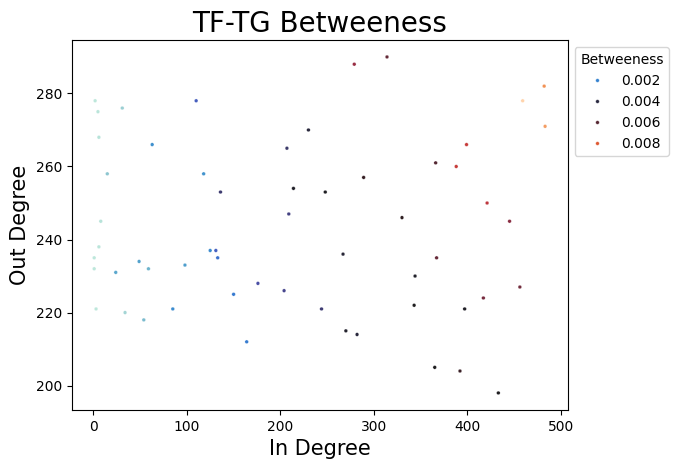

In [17]:
fig, ax = plt.subplots(1)
sns.scatterplot(TFTG_df, x = 'in degree', y = 'out degree', hue = 'Betweeness', s = 7, palette = 'icefire')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_ylabel('Out Degree', fontsize = 15)
ax.set_xlabel('In Degree', fontsize = 15)
ax.set_title('TF-TG Betweeness', fontsize = 20)
#plt.savefig('./figures/InOutBetweenessTFTG', dpi = 300)

# Indetifying G clusters and cluster hubs

In [18]:
import networkx as nx
from networkx.algorithms.community import louvain_communities

clusters = louvain_communities(G, seed=42)

for i, cluster in enumerate(clusters):
    print(f"Cluster {i}: {cluster}")

Cluster 0: {'POU2AF1', 'CCNB1', 'BID', 'MYH7', 'ZNF296', 'ZFP28', 'ATF1', 'CUX2', 'ANXA3', 'ATF3', 'HOXA13', 'CLDND1', 'FBF1', 'MFSD4B', 'SCX', 'SMIM19', 'KLF2', 'USF2', 'ANKRD22', 'ZBTB26', 'ZNF148', 'KIR2DL4', 'GOLGA7B', 'A2ML1', 'ZBTB40', 'ZNF273', 'PSMB6', 'KLF10', 'SLC51A', 'CGN', 'ZBTB21', 'CEBPB', 'TEAD4', 'FOS', 'NPAS3', 'HOXC6', 'PRDM9', 'EXOC3', 'CPSF4', 'NTF4', 'ESR2', 'GABARAPL1', 'MLC1', 'DLX4', 'ZFP69', 'CREB3L1', 'FABP6', 'OVOL2', 'NKX2-2', 'ZSCAN26', 'KCNQ2', 'REST', 'PINK1', 'ZNF211', 'NDUFA13', 'METRN', 'SMAD9', 'NEUROD1', 'ECH1', 'DHRS4', 'ABHD5', 'EYA4', 'MDH2', 'CD69', 'ZNF549', 'IL1R2', 'CREB3L2', 'ZNF398', 'RIPK1', 'HIVEP2', 'PCDHB3', 'CIC', 'FGF7', 'TP53', 'CENPA', 'ZNF623', 'HOXA10', 'MFAP4', 'F2RL1', 'UGT1A6', 'KIF23', 'ARID3C', 'LPIN3', 'ZNF382', 'ZNF714', 'ADAMTSL1', 'EPB41L1', 'ZHX1', 'PRDM1', 'MAGEL2', 'DOCK8', 'ZNF282', 'TGIF1', 'COL4A1', 'ATF6B', 'ZNF655', 'GABPA', 'KIF26A', 'PDCD11', 'CDH7', 'YME1L1', 'ZNF423', 'KDM5B', 'ZNF543', 'MPHOSPH10', 'GAPT', 'S

In [19]:
def find_cluster_hubs(graph, communities):
    hubs = {}
    for i, community in enumerate(communities):
        # Create a subgraph for just this cluster
        subgraph = graph.subgraph(community)
        
        # Find the node with the highest degree in this subgraph
        cluster_hub = max(subgraph.degree, key=lambda x: x[1])[0]
        hubs[i] = cluster_hub
        
    return hubs

cluster_hubs = find_cluster_hubs(G, clusters)
print("\nCluster Hubs:", cluster_hubs)


Cluster Hubs: {0: 'FBF1', 1: 'MBL2', 2: 'ZBTB7A', 3: 'GPR171', 4: 'FOXP3', 5: 'AHRR', 6: 'CTCFL', 7: 'ZKSCAN1', 8: 'CIDEC'}


# Comparing DEGs to differential regulators

In [111]:
with open('/home/alexanderb/Zhang_lab/MML_model/model_evaluation/male_v_female/data/DGEs.txt', 'r') as file:
    lines = file.readlines()
DGEs = []
for line in lines:
    DGEs.append(line.strip('\n'))

In [112]:
DGEs

['FRMD6',
 'HSD11B1',
 'GRB14',
 'CYP2C19',
 'BACE2',
 'TBC1D14',
 'ZNF66',
 'ASTN1',
 'CHRD',
 'GBP5',
 'RHOF',
 'SERPINE1',
 'NUDT13',
 'SYT9',
 'RARRES1',
 'CD96',
 'SPIDR',
 'CCDC177',
 'GABBR1',
 'FSTL3',
 'FNBP4',
 'UBE2QL1',
 'DOCK5',
 'CD47',
 'LENG8',
 'RRM2',
 'TRIB3',
 'ZNF274',
 'RAB37',
 'CNTNAP2',
 'CPE',
 'CYP1A1',
 'DTX1',
 'SYTL5',
 'MTMR11',
 'FKBP1B',
 'RUNX2',
 'FOXP3',
 'LAMP3',
 'PFN2',
 'KCNB1',
 'NOL4',
 'NUCB2',
 'SDCCAG8',
 'ARRB2',
 'KIF1A',
 'PIP4P2',
 'MMP3',
 'TENT4A',
 'CPT1B',
 'DNAH11',
 'LHFPL5',
 'PPT2',
 'NHP2',
 'ZNF382',
 'USP35',
 'AKR1C3',
 'NLGN2',
 'ZNF273',
 'EIF6',
 'ZRSR2',
 'SUPT7L',
 'CCDC69',
 'CPEB3',
 'GPR171',
 'ZNF780A',
 'TRABD2B',
 'TRAF1',
 'AJUBA',
 'ZNF69',
 'KLRK1',
 'LAD1',
 'TBX3',
 'ZFP36L2',
 'RAB13',
 'CLK4',
 'MGLL',
 'SLC2A4',
 'KL',
 'PIR',
 'SPESP1',
 'RAB2B',
 'RHCG',
 'AMOTL1',
 'MARVELD3',
 'ELMOD3',
 'FAM153A',
 'HSPA7',
 'EGFR',
 'PUDP',
 'ALG10',
 'MRPS15',
 'FOXA1',
 'TNFRSF25',
 'GCNT2',
 'CLEC2D',
 'ZNF514',
 '

In [ ]:
/home/alexanderb/Zhang_lab/MML_model/GRN_reconstruction/data/0.1_differential_all.txt

In [113]:
with open('/home/alexanderb/Zhang_lab/MML_model/GRN_reconstruction/data/0.1_differential_all.txt', 'r') as file:
    lines = file.readlines()
diff_regs = []
for line in lines:
    diff_regs.append(line.strip('\n'))

In [117]:
len(set(diff_regs) & set(DGEs))

159